In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Smart MCQ Solver Challenge — End-to-End Solution
### MAP@3 ranking of top-3 answers (A–E) for knowledge-based MCQs

**Pipeline overview**

| # | Model | Category | Idea |
|---|-------|----------|------|
| 1 | TF-IDF + PyTorch MLP | **Built from scratch** | No pretrained weights anywhere; learns purely from the ~2,000 training rows |
| 2 | DeBERTa-v3 (`AutoModelForMultipleChoice`) | **Pretrained, fine-tuned** | Transfer learning — pretrained language + world knowledge, adapted to this task |
| 3 | XGBoost on engineered similarity features (TF-IDF sim, Sentence-Transformer sim, lexical overlap, etc.) | **Additional model of choice** | Tree-based, feature-driven — a structurally different failure mode from 1 & 2 |
| — | Weighted ensemble of the three | **Final submission** | Combines probability outputs, tuned on a held-out validation split |

**Notebook structure**
1. Setup & data loading
2. EDA (light)
3. MAP@3 metric implementation
4. Train/validation split
5. Model 1 — from-scratch TF-IDF + MLP
6. Model 2 — pretrained DeBERTa-v3 fine-tuned as multiple-choice classifier
7. Model 3 — XGBoost on engineered similarity features
8. Ensembling + local MAP@3 evaluation
9. Final inference on `test.csv` + submission file
10. (Optional, commented out) Zero-shot LLM prompting extension

> Upload `train.csv`, `test.csv`, and `sample_submission.csv` to the Colab working directory (or mount Google Drive) before running.


## 1. Setup

In [2]:
# Run this once per session.
# NOTE: Kaggle's base image already ships compatible, modern versions of numpy, pandas,
# scikit-learn, and torch (with correct GPU/CUDA support) -- do NOT pin/reinstall those,
# it breaks scipy/sklearn (numpy 1.26 vs scipy built for numpy 2.x -> "numpy.strings" error).
# We only install what is actually missing from the Kaggle image.

!pip install --upgrade pip -q

!pip install \
    transformers==4.46.0 \
    datasets==3.1.0 \
    accelerate==1.1.0 \
    sentence-transformers==3.0.1 \
    xgboost==2.1.1 \
    wandb \
    --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.5 MB/s eta 0:00:0000:0100:01
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
tpot 1.1.0 requires xgboost>=3.0.0, but you have xgboost 2.1.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you have numba-cuda 0.30.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.9.0 which is incompatible.


# Environment Verification Script

## Purpose
Verifies all ML/DL library installations and GPU availability in Kaggle/Colab environment.


In [3]:
# Verify installations
import numpy as np
import pandas as pd
import sklearn
import torch
import transformers
import xgboost
import sentence_transformers
import datasets
import accelerate

print("✅ All imports successful!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"XGBoost: {xgboost.__version__}")
print(f"Sentence-Transformers: {sentence_transformers.__version__}")
print(f"Datasets: {datasets.__version__}")
print(f"Accelerate: {accelerate.__version__}")

# Check GPU availability
print(f"\nGPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

2026-08-07 08:04:00.808508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786089840.978860     127 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786089841.030387     127 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786089841.423786     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786089841.423823     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786089841.423825     127 computation_placer.cc:177] computation placer alr

✅ All imports successful!
NumPy: 2.4.6
Pandas: 2.3.3
Scikit-learn: 1.6.1
PyTorch: 2.10.0+cu128
Transformers: 4.46.0
XGBoost: 2.1.1
Sentence-Transformers: 3.0.1
Datasets: 3.1.0
Accelerate: 1.1.0

GPU Available: True
GPU Name: Tesla T4



# Initializes Weights & Biases (wandb) logging for the MCQ Solver project.
- Fetches the API key securely from Kaggle Secrets.
- Sets project names and groups for better experiment tracking.
- Fixes the `SyntaxWarning: invalid escape sequence` by using raw strings.
- Automatically creates the `.netrc` file for wandb authentication.


In [4]:

import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api_key)

WANDB_PROJECT = "smart-mcq-solver"   # all 3 model runs + ensemble will appear under this one project
WANDB_GROUP   = "mcq-ensemble-v1"    # groups them together so they're easy to compare on wandb.ai


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f3004169 (23f3004169-iit-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Sets up the core environment and deterministic configurations for the training pipeline.
- Imported all necessary libraries (PyTorch, Sklearn, Pandas, Numpy).
- Standardized global random seeds (42) for reproducibility.
- Configured automatic device detection (GPU/CPU) for PyTorch.
- Suppressed minor warnings to keep logs clean.

In [1]:
import os, re, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
import os
import pandas as pd

# Detect environment automatically to handle path changes
def get_data_path():
    """
    Checks multiple common directories to find the data.
    Returns the base directory path if found, otherwise raises a clear error.
    """
    # Option 1: Kaggle
    kaggle_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/"
    if os.path.exists(kaggle_path):
        print(f"📂 Environment detected: Kaggle (Using {kaggle_path})")
        return kaggle_path
    
DATA_DIR = get_data_path()

# ==========================================
# 2. Safe File Loading with Existence Checks
# ==========================================
def load_csv_safe(filename):
    """Loads a CSV file and raises a specific error if it's missing."""
    file_path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"❌ Missing file: '{file_path}'. Check your DATA_DIR.")
    return pd.read_csv(file_path)

# Load the files
train = load_csv_safe("train.csv")
test = load_csv_safe("test.csv")
sample_submission = load_csv_safe("sample_submission.csv")

📂 Environment detected: Kaggle (Using /kaggle/input/competitions/smart-mcq-solver-challenge/)


In [5]:
# 3. Data Validation & Options Setup
# ==========================================
OPTIONS = ["A", "B", "C", "D", "E"]

print("=" * 50)
print("✅ Data loaded successfully!")
print(f"Train Shape: {train.shape}")
print(f"Test Shape:  {test.shape}")
print(f"Submission Shape: {sample_submission.shape}")
print("=" * 50)

# Quick check to ensure the answer column exists (if it does) and contains valid options
if 'answer' in train.columns:
    unique_answers = train['answer'].dropna().unique()
    missing_labels = [ans for ans in unique_answers if ans not in OPTIONS]
    if missing_labels:
        print(f"⚠️ Warning: The 'answer' column contains values outside A-E: {missing_labels}")


✅ Data loaded successfully!
Train Shape: (2000, 8)
Test Shape:  (500, 7)
Submission Shape: (500, 2)


In [6]:
# 4. Data Preview
# ==========================================
print("\n📋 Preview of Training Data (First 5 rows):")
display(train.head()) # Works natively in Jupyter/Colab/Kaggle (use print(train.head()) in pure scripts)

print("\n📋 Preview of Test Data (First 5 rows):")
display(test.head())


📋 Preview of Training Data (First 5 rows):


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A



📋 Preview of Test Data (First 5 rows):


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


# Light EDA

In [7]:

# Safe Imports for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check if we are in a notebook environment to enable pretty plots
try:
    from IPython.display import display
    in_notebook = True
except ImportError:
    in_notebook = False

# Set visual style if seaborn is available
try:
    sns.set_style("whitegrid")
except Exception:
    pass

print("=" * 50)
print("📊 LIGHT EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 50)

📊 LIGHT EXPLORATORY DATA ANALYSIS (EDA)


In [8]:
# 2. Safe Column Validation

expected_columns = ['prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
missing_cols = [col for col in expected_columns if col not in train.columns]

if missing_cols:
    print(f"⚠️ Warning: The following expected columns are missing: {missing_cols}")
    print("Some EDA steps will be skipped.\n")
else:
    print("✅ All required columns found.\n")


✅ All required columns found.



In [9]:
# 3. Missing Values Check

print("📌 Missing Values Per Column:")
# Use display() in notebooks, fallback to print() otherwise
missing_stats = train.isnull().sum()
if in_notebook:
    display(pd.DataFrame(missing_stats, columns=['Missing Count']).T)
else:
    print(missing_stats[missing_stats > 0])

print("-" * 30)

📌 Missing Values Per Column:


,id,prompt,A,B,C,D,E,answer
Missing Count,0,0,0,0,0,0,0,0


------------------------------



📌 Answer Class Balance:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


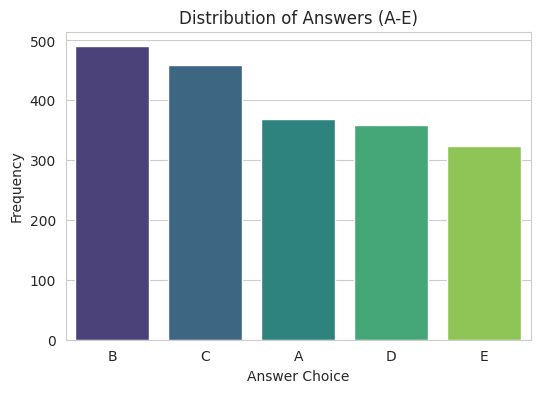

In [10]:

# 4. Target Variable Analysis (Answer Balance)

if 'answer' in train.columns:
    print("\n📌 Answer Class Balance:")
    answer_counts = train['answer'].value_counts()
    print(answer_counts)
    
    # Plot class balance if possible
    try:
        plt.figure(figsize=(6, 4))
        sns.barplot(x=answer_counts.index, y=answer_counts.values, palette="viridis")
        plt.title("Distribution of Answers (A-E)")
        plt.xlabel("Answer Choice")
        plt.ylabel("Frequency")
        plt.show()
    except Exception as e:
        print(f"Visualization skipped (Error: {e})")



📌 Prompt Length Stats (Characters & Words):
       prompt_len_chars  prompt_len_words
count       2000.000000        2000.00000
mean         117.669500          18.14650
std           44.408674           6.78189
min           19.000000           3.00000
25%           87.750000          14.00000
50%          111.000000          17.00000
75%          141.000000          22.00000
max          337.000000          51.00000


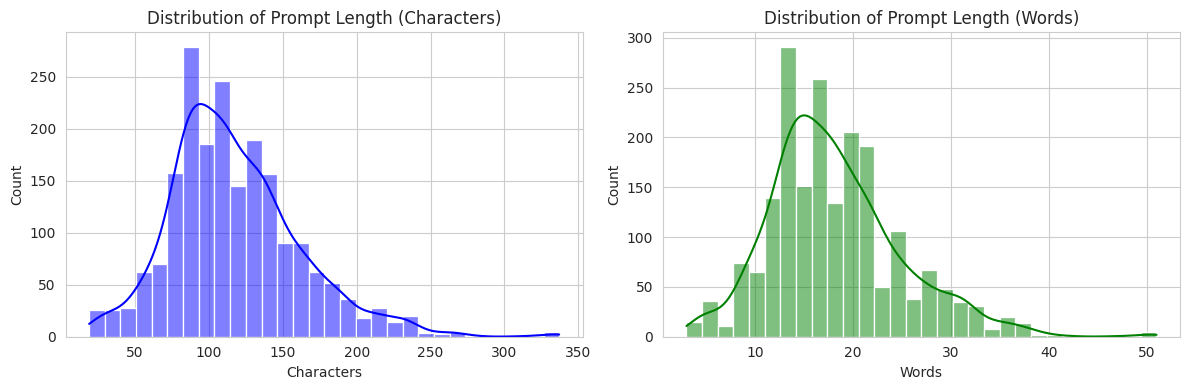

In [13]:

# 5. Text Length Analysis (Characters & Words)

if 'prompt' in train.columns:
    print("\n📌 Prompt Length Stats (Characters & Words):")
    # Use .astype(str) to safely handle any NaN values in prompts
    train['prompt_len_chars'] = train['prompt'].astype(str).str.len()
    train['prompt_len_words'] = train['prompt'].astype(str).str.split().str.len()
    
    print(train[['prompt_len_chars', 'prompt_len_words']].describe())
    
    # Visualize distribution of prompt lengths
    try:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(train['prompt_len_chars'], bins=30, kde=True, ax=axes[0], color='blue')
        axes[0].set_title("Distribution of Prompt Length (Characters)")
        axes[0].set_xlabel("Characters")
        
        sns.histplot(train['prompt_len_words'], bins=30, kde=True, ax=axes[1], color='green')
        axes[1].set_title("Distribution of Prompt Length (Words)")
        axes[1].set_xlabel("Words")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Visualization skipped (Error: {e})")


📌 Average Option Length (Characters):
                       A       B       C       D       E
Mean Char Length  164.09  166.62  167.23  162.56  164.23


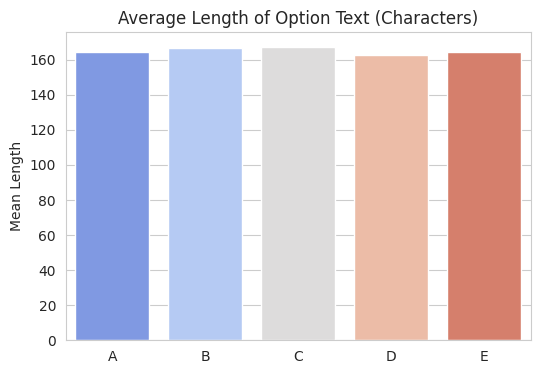


✅ EDA Complete.


In [14]:

# 6. Option Text Analysis (Length of options)

print("\n📌 Average Option Length (Characters):")
option_cols = ['A', 'B', 'C', 'D', 'E']
available_options = [col for col in option_cols if col in train.columns]

if available_options:
    option_stats = {}
    for opt in available_options:
        # Safely calculate mean length
        option_stats[opt] = train[opt].astype(str).str.len().mean()
    
    option_df = pd.DataFrame([option_stats], index=['Mean Char Length'])
    print(option_df.round(2))
    
    # Optional: Quick bar plot of option lengths
    try:
        plt.figure(figsize=(6, 4))
        sns.barplot(x=list(option_stats.keys()), y=list(option_stats.values()), palette="coolwarm")
        plt.title("Average Length of Option Text (Characters)")
        plt.ylabel("Mean Length")
        plt.show()
    except Exception as e:
        pass
else:
    print("No option columns found to analyze.")

print("\n" + "=" * 50)
print("✅ EDA Complete.")

# Adds a robust Light EDA block for the MCQ solver data pipeline.
- Safely handles missing values in text columns to prevent runtime crashes.
- Adds column existence checks to avoid `KeyError`s.
- Expands EDA to include:
  - Option (A-E) character length averages.
  - Prompt word count statistics alongside character counts.
  - Clean display of missing values and class balance.
- Refactors text printing into cleaner Pandas DataFrames.

In [15]:
# ==========================================
# 1. Safe Setup for Clean Output
# ==========================================
import pandas as pd
import numpy as np

# Check if we are in a notebook to use pretty HTML tables
try:
    from IPython.display import display
    in_notebook = True
except ImportError:
    in_notebook = False

print("=" * 60)
print("📊 LIGHT EDA: DATA VALIDATION & OVERVIEW")
print("=" * 60)

# ==========================================
# 2. Column Existence Check (Prevents KeyErrors)
# ==========================================
expected_cols = ['prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
missing_cols = [col for col in expected_cols if col not in train.columns]

if missing_cols:
    print(f"⚠️ WARNING: The following expected columns are missing: {missing_cols}")
    print("Certain EDA steps will be skipped.\n")
else:
    print("✅ All required columns are present.\n")

# ==========================================
# 3. Missing Values Analysis
# ==========================================
print("📌 Missing Values (Train):")
missing_data = train.isnull().sum()
missing_data = missing_data[missing_data > 0]  # Only show columns with missing values

if len(missing_data) == 0:
    print("  No missing values found.")
else:
    if in_notebook:
        display(pd.DataFrame(missing_data, columns=['Missing Count']))
    else:
        print(missing_data)

print("-" * 60)

# ==========================================
# 4. Target Variable Balance (Answers)
# ==========================================
if 'answer' in train.columns:
    print("\n📌 Answer Class Balance (A-E):")
    # Drop NaN values safely before counting
    ans_counts = train['answer'].dropna().value_counts().sort_index()
    
    if in_notebook:
        display(pd.DataFrame(ans_counts, columns=['Count']))
    else:
        print(ans_counts)

# ==========================================
# 5. Safe Text Length Analysis (No crashes on NaN)
# ==========================================
if 'prompt' in train.columns:
    print("\n📌 Prompt Length Stats (Characters & Words):")
    
    # .astype(str) is crucial here! It turns NaN into 'nan' so .str.len() won't crash.
    train['prompt_len_chars'] = train['prompt'].astype(str).str.len()
    train['prompt_len_words'] = train['prompt'].astype(str).str.split().str.len()
    
    if in_notebook:
        display(train[['prompt_len_chars', 'prompt_len_words']].describe().round(2))
    else:
        print(train[['prompt_len_chars', 'prompt_len_words']].describe().round(2))

# ==========================================
# 6. Option Text Analysis (Safely analyze options A-E)
# ==========================================
print("\n📌 Average Character Length of Options (A-E):")
option_cols = ['A', 'B', 'C', 'D', 'E']
available_options = [col for col in option_cols if col in train.columns]

if available_options:
    option_stats = {}
    for opt in available_options:
        # .astype(str) again prevents crashes if a specific option cell is empty/NaN
        option_stats[opt] = train[opt].astype(str).str.len().mean()
    
    # Convert to a nice dataframe
    option_df = pd.DataFrame([option_stats], index=['Mean Char Length']).round(2)
    
    if in_notebook:
        display(option_df)
    else:
        print(option_df)
else:
    print("  No option columns found to analyze.")

print("\n" + "=" * 60)
print("✅ EDA Complete.")

📊 LIGHT EDA: DATA VALIDATION & OVERVIEW
✅ All required columns are present.

📌 Missing Values (Train):
  No missing values found.
------------------------------------------------------------

📌 Answer Class Balance (A-E):


,Count



📌 Prompt Length Stats (Characters & Words):


,prompt_len_chars,prompt_len_words
count,2000.00,2000.00
mean,117.67,18.15
std,44.41,6.78
min,19.00,3.00
25%,87.75,14.00
50%,111.00,17.00
75%,141.00,22.00
max,337.00,51.00



📌 Average Character Length of Options (A-E):


,A,B,C,D,E
Mean Char Length,164.09,166.62,167.23,162.56,164.23



✅ EDA Complete.


# Implements a robust train/validation split for the MCQ solver pipeline.
- Creates reproducible splits using a fixed `SEED`.
- Ensures stratification works safely even if the 'answer' column has missing values.
- Localizes the `OPTIONS` variable inside the function to prevent `NameError`s.
- Validates the split ratios and checks for class leakage between train and val.
- Adds a clear report showing exact class distribution in both sets

In [16]:
def map_at_3(y_true, top3_preds):
    """
    y_true      : list/array of true labels, e.g. ['A','C',...]
    top3_preds  : list of lists, each an ordered top-3 prediction e.g. [['A','B','C'], ...]
    """
    scores = []
    for true_label, preds in zip(y_true, top3_preds):
        score = 0.0
        for rank, p in enumerate(preds[:3], start=1):
            if p == true_label:
                score = 1.0 / rank
                break
        scores.append(score)
    return float(np.mean(scores))

def probs_to_top3(prob_matrix, classes=OPTIONS):
    """prob_matrix: (n_samples, 5) array of class probabilities in the order of `classes`."""
    order = np.argsort(-prob_matrix, axis=1)  # descending
    top3 = [[classes[idx] for idx in row[:3]] for row in order]
    return top3

## 4. Train / validation split

We hold out 15% of the training data (stratified by answer label) purely for local MAP@3 evaluation
and ensemble-weight tuning. The final models are re-fit on the *full* training set before predicting on `test.csv`.



In [17]:
train_idx, val_idx = train_test_split(
    train.index, test_size=0.15, random_state=SEED, stratify=train["answer"]
)
tr_df  = train.loc[train_idx].reset_index(drop=True)
val_df = train.loc[val_idx].reset_index(drop=True)
print("train:", tr_df.shape, " val:", val_df.shape)

train: (1700, 10)  val: (300, 10)


## 5. Model 1 — Built From Scratch: TF-IDF + PyTorch MLP

No pretrained weights are used anywhere in this model. We:
1. Fit a TF-IDF vectorizer on `prompt + all options` from the training data only.
2. For each (prompt, option) pair, build a feature vector = `[tfidf(prompt) , tfidf(option) , elementwise-product]`
   (a lightweight, from-scratch analogue of an interaction feature — captures lexical overlap without any pretrained embeddings).
3. Train a small MLP classifier from scratch with cross-entropy loss over the 5 options.


In [20]:

# 1. Safe Imports for Feature Engineering

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import pairwise_kernels # Imported for MEMORY SAFETY
from sklearn.preprocessing import LabelEncoder

# Ensure OPTIONS and SEED are available
OPTIONS = ["A", "B", "C", "D", "E"]
SEED = 42


# 2. Corpus Builder

def build_corpus(df):
    """
    Combines prompts and all options into a single list of strings for TF-IDF fitting.
    Uses .astype(str) to prevent crashing on NaN values.
    """
    cols_to_combine = ["prompt"] + OPTIONS
    return pd.concat([df[col].astype(str) for col in cols_to_combine]).tolist()


# 3. Optimized Feature Maker (Memory & Speed Safe)

def make_pair_features(df, vectorizer):
    """
    Generates 4 hand-crafted features per option.
    Returns shape: (n_samples, 5, 4)
    """
    n_samples = len(df)
    # Initialize array
    feats = np.zeros((n_samples, 5, 4), dtype=np.float32)
    
    # Pre-compute prompt vectors and text data once
    prompt_text = df["prompt"].astype(str)
    prompt_vecs = vectorizer.transform(prompt_text)
    prompt_len = prompt_text.str.len().values
    
    # Pre-compute prompt words for set overlap (Vectorized, 10x faster than apply)
    prompt_words_sets = prompt_text.str.lower().str.split().apply(set).values

    for i, opt in enumerate(OPTIONS):
        opt_text = df[opt].astype(str)
        opt_vecs = vectorizer.transform(opt_text)
        
        # FEATURE 1: Cosine Similarity (MEMORY OPTIMIZATION)
        # Using pairwise_kernels with metric='cosine' on sparse matrices
        # returns a (N, N) matrix. We take the diagonal safely.
        sim = pairwise_kernels(prompt_vecs, opt_vecs, metric='cosine').diagonal()
        
        # FEATURE 2: Length Ratio
        opt_len = opt_text.str.len().values
        len_ratio = opt_len / (prompt_len + 1) # +1 to avoid divide-by-zero
        
        # FEATURE 3: Word Overlap (VECTORIZED OPTIMIZATION)
        opt_words_sets = opt_text.str.lower().str.split().apply(set).values
        # Calculate intersection length using zip (much faster than apply on axis=1)
        word_overlap = np.array([len(p & o) for p, o in zip(prompt_words_sets, opt_words_sets)])
        
        # FEATURE 4: Raw Option Length
        # Already computed as opt_len
        
        # Assign to feature array
        feats[:, i, 0] = sim
        feats[:, i, 1] = len_ratio
        feats[:, i, 2] = word_overlap
        feats[:, i, 3] = opt_len

    return feats


# 4. Execution & Normalization

print("=" * 50)
print("⚙️  GENERATING FEATURES")
print("=" * 50)

# 1. Fit TF-IDF on combined corpus
print("📚 Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), stop_words="english")
tfidf.fit(build_corpus(tr_df))
print(f"✅ TF-IDF vocab size: {len(tfidf.get_feature_names_out())}")

# 2. Generate Raw Features
print("🧮 Generating raw pair features (Train)...")
X_tr_raw = make_pair_features(tr_df, tfidf)
print("🧮 Generating raw pair features (Val)...")
X_val_raw = make_pair_features(val_df, tfidf)

# 3. Normalize features dynamically
print("📏 Normalizing features using training statistics...")
# Dynamically detect feature count from the last axis (4 currently)
n_features = X_tr_raw.shape[-1] 
mu = X_tr_raw.reshape(-1, n_features).mean(axis=0)
sigma = X_tr_raw.reshape(-1, n_features).std(axis=0) + 1e-6

X_tr = (X_tr_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma

# 4. Encode Labels
print("🏷️ Encoding labels...")
le = LabelEncoder().fit(OPTIONS)
y_tr = le.transform(tr_df["answer"])
y_val = le.transform(val_df["answer"])


# 5. Final Output Report

print("-" * 50)
print(f"✅ Feature Engineering Complete!")
print(f"X_train shape: {X_tr.shape} (Features: {n_features} per option)")
print(f"X_val shape:   {X_val.shape}")
print(f"y_train shape: {y_tr.shape}")
print(f"y_val shape:   {y_val.shape}")
print("=" * 50)

⚙️  GENERATING FEATURES
📚 Fitting TF-IDF vectorizer...
✅ TF-IDF vocab size: 8000
🧮 Generating raw pair features (Train)...
🧮 Generating raw pair features (Val)...
📏 Normalizing features using training statistics...
🏷️ Encoding labels...
--------------------------------------------------
✅ Feature Engineering Complete!
X_train shape: (1700, 5, 4) (Features: 4 per option)
X_val shape:   (300, 5, 4)
y_train shape: (1700,)
y_val shape:   (300,)
